# Surrogate model — readouts over per-residue ESM-2 embeddings

Goal: a **good** surrogate `g(seq) -> spectrum`, moving off **mean pooling** (which averages away the few
chromophore residues that set FP color). We compare readouts head-to-head on the cluster-split surrogate
test set, then train/tune/save the winner.

**Finding (see comparison below):** learned **attention pooling overfits** at this data scale (~317 train
sequences in a few families) — great val, poor held-out test. Plain **max pooling** wins: best test accuracy,
no extra parameters, and it keeps the strongest per-feature activation across residues (sensitive to the
decisive chromophore positions). The bottleneck here is data/few-families, not the pooling.

## 0. Setup + data + per-residue embeddings (cached)

In [1]:
import csv, os, time, itertools
import numpy as np, torch, torch.nn as nn, esm
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32)
grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EXM=np.array([float(r["ex_max"]) for r in rows]); EMM=np.array([float(r["em_max"]) for r in rows])
sur=np.array([r["surrogate_split"] for r in rows])
cluster=np.array([int(r["cluster"]) for r in rows])
seqs=[None]*N; h=None
for line in open(os.path.join(TD,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
m={b:np.where(sur==b)[0] for b in("train","val","test")}
print("device",dev,"| surrogate",{b:len(v) for b,v in m.items()})

device mps | surrogate {'train': 317, 'val': 68, 'test': 68}


In [2]:
# per-residue layer-33 embeddings, cached as fp16 (N, Lmax, 1280) + lengths
RP=os.path.join(TD,"esm_residue_fp16.npy"); LP=os.path.join(TD,"esm_residue_len.npy")
if os.path.exists(RP) and np.load(LP).shape[0]==N:
    H=np.load(RP); Ls=np.load(LP); print("loaded per-residue cache", H.shape)
else:
    model,alphabet=esm.pretrained.esm2_t33_650M_UR50D(); model=model.eval().to(dev)
    for p in model.parameters(): p.requires_grad_(False)
    bc=alphabet.get_batch_converter(); Lmax=max(len(s) for s in seqs)
    H=np.zeros((N,Lmax,1280),dtype=np.float16); Ls=np.zeros(N,dtype=np.int64); t=time.time()
    with torch.no_grad():
        for i in range(0,N,16):
            ch=seqs[i:i+16]; _,_,tk=bc([(f"s{j}",s) for j,s in enumerate(ch)]); tk=tk.to(dev)
            reps=model(tk,repr_layers=[33])["representations"][33]
            for j,s in enumerate(ch):
                n=len(s); H[i+j,:n]=reps[j,1:1+n].float().cpu().numpy().astype(np.float16); Ls[i+j]=n
    np.save(RP,H); np.save(LP,Ls); print(f"cached per-residue {H.shape} in {time.time()-t:.0f}s")
Lmax=H.shape[1]; rmask=(np.arange(Lmax)[None,:]<Ls[:,None])   # (N,L) valid-residue mask

loaded per-residue cache (453, 476, 1280)


## 1. Readouts + metrics

Fixed poolings (no learned params) and a learned multi-head **attention pooling** module.

In [3]:
Hf=H.astype(np.float32); MK=rmask[:,:,None]
def pooled(kind):
    mean=(Hf*MK).sum(1)/MK.sum(1).clip(1)
    if kind=="mean": return mean
    mx=np.where(MK, Hf, -1e9).max(1)
    if kind=="max": return mx
    if kind=="mean+max": return np.concatenate([mean,mx],1)
    std=np.sqrt((((Hf-mean[:,None,:])**2)*MK).sum(1)/MK.sum(1).clip(1)+1e-8)
    return np.concatenate([mean,mx,std],1)            # mean+max+std

def exem(S): return grid[np.argmax(S[:,:G],1)], grid[np.argmax(S[:,G:],1)]
def metrics(P, idx):
    T=Y[idx]; ex,em=exem(P)
    return dict(mse=float(((P-T)**2).mean()),
                ex_mae=float(np.abs(ex-EXM[idx]).mean()),
                em_mae=float(np.abs(em-EMM[idx]).mean()))
BASE=Y[m["train"]].mean(0,keepdims=True)
print("baseline (mean spectrum) test:", metrics(np.repeat(BASE,len(m["test"]),0), m["test"]))

baseline (mean spectrum) test: {'mse': 0.07001520693302155, 'ex_mae': 97.19117647058823, 'em_mae': 91.98529411764706}


In [4]:
class AttnPool(nn.Module):
    def __init__(s,d_in=1280,d=128,heads=1,hidden=256,out=2*G,drop=0.3,indrop=0.2):
        super().__init__(); s.indrop=nn.Dropout(indrop); s.proj=nn.Linear(d_in,d)
        s.heads=heads; s.dh=d//heads; s.q=nn.Parameter(torch.randn(heads,s.dh)*0.1)
        s.mlp=nn.Sequential(nn.Linear(d,hidden),nn.ReLU(),nn.Dropout(drop),nn.Linear(hidden,out))
    def forward(s,Hb,mask):
        Hb=s.indrop(Hb); x=s.proj(Hb); B,L,d=x.shape; xh=x.view(B,L,s.heads,s.dh)
        sc=torch.einsum('blhd,hd->blh',xh,s.q)/(s.dh**0.5)
        sc=sc.masked_fill(~mask.unsqueeze(-1),float('-inf'))
        a=torch.softmax(sc,1); pooled=torch.einsum('blh,blhd->bhd',a,xh).reshape(B,d)
        return s.mlp(pooled)

Ht=torch.tensor(H); ar=torch.arange(Lmax)
def attn_batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),torch.tensor(Y[b]).to(dev)
def train_attention(cfg,wd=1e-3,epochs=200,patience=30,seed=0):
    torch.manual_seed(seed); net=AttnPool(**cfg).to(dev)
    opt=torch.optim.Adam(net.parameters(),1e-3,weight_decay=wd); lf=nn.MSELoss(); best=1e9;bst=None;wait=0
    for ep in range(epochs):
        net.train()
        for Hb,mk,yb in attn_batches(m["train"],shuffle=True): opt.zero_grad();lf(net(Hb,mk),yb).backward();opt.step()
        net.eval(); ps=[]
        with torch.no_grad():
            for Hb,mk,yb in attn_batches(m["val"]): ps.append(net(Hb,mk).cpu().numpy())
        v=((np.concatenate(ps)-Y[m["val"]])**2).mean()
        if v<best-1e-5: best=v;bst={k:vv.cpu().clone() for k,vv in net.state_dict().items()};wait=0
        else: wait+=1
        if wait>=patience: break
    net.load_state_dict(bst); net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,yb in attn_batches(m["test"]): ps.append(net(Hb,mk).cpu().numpy())
    return net,best,np.concatenate(ps)

In [5]:
def make_mlp(din,dh,out,nl=2,drop=0.1):
    L=[nn.Linear(din,dh),nn.ReLU()]
    for _ in range(nl-1): L+=[nn.Dropout(drop),nn.Linear(dh,dh),nn.ReLU()]
    L+=[nn.Linear(dh,out)]; return nn.Sequential(*L)
def train_mlp(X,cfg,seed=0):
    Xt=torch.tensor(np.asarray(X,dtype=np.float32)).to(dev); Yt=torch.tensor(Y).to(dev)
    tr=torch.tensor(m["train"]); va=torch.tensor(m["val"]); torch.manual_seed(seed)
    net=make_mlp(X.shape[1],cfg["hidden"],2*G,cfg["nl"],cfg["drop"]).to(dev)
    opt=torch.optim.Adam(net.parameters(),cfg.get("lr",1e-3),weight_decay=cfg["wd"]); lf=nn.MSELoss()
    best=1e9;bst=None
    for ep in range(cfg.get("epochs",500)):
        net.train();opt.zero_grad();lf(net(Xt[tr]),Yt[tr]).backward();opt.step()
        if ep%10==0:
            net.eval()
            with torch.no_grad(): v=lf(net(Xt[va]),Yt[va]).item()
            if v<best:best=v;bst={k:vv.cpu().clone() for k,vv in net.state_dict().items()}
    net.load_state_dict(bst);net.eval()
    with torch.no_grad(): P=net(Xt[torch.tensor(m["test"])]).cpu().numpy()
    return net,best,P

## 2. Head-to-head: which readout generalizes?

Same MLP head + protocol for each fixed pooling; the attention model uses its own (regularized) head. Selected
by surrogate-val, reported on the held-out surrogate-**test** clusters.

In [6]:
cfg0=dict(hidden=256,nl=2,drop=0.1,wd=1e-4)
results={}
for k in ("mean","max","mean+max","mean+max+std"):
    _,bv,P=train_mlp(pooled(k),cfg0); results[k]=(bv,metrics(P,m["test"]))
_,bva,Pa=train_attention(dict(heads=1,d=128,hidden=256,drop=0.3,indrop=0.2)); results["attention"]=(bva,metrics(Pa,m["test"]))

print(f"{'readout':16s} {'valMSE':>8} {'testMSE':>8} {'ex_MAE':>7} {'em_MAE':>7}")
for k,(bv,mt) in results.items():
    print(f"{k:16s} {bv:8.5f} {mt['mse']:8.5f} {mt['ex_mae']:7.1f} {mt['em_mae']:7.1f}")
print(f"{'baseline':16s} {'-':>8} " + "{:8.5f} {:7.1f} {:7.1f}".format(*[metrics(np.repeat(BASE,len(m['test']),0),m['test'])[x] for x in('mse','ex_mae','em_mae')]))

readout            valMSE  testMSE  ex_MAE  em_MAE
mean              0.03718  0.06869    98.3    91.3
max               0.03521  0.04920    50.2    44.0
mean+max          0.03662  0.05542    53.3    46.7
mean+max+std      0.03660  0.05201    52.7    44.5
attention         0.03652  0.06960    97.2    92.6
baseline                -  0.07002    97.2    92.0


## 3. Train, tune & save the chosen surrogate (max pooling)

Max pooling won the comparison. Grid-search the MLP head over it (selected on val), save the best, and report
final surrogate-test performance.

In [7]:
from sklearn.model_selection import GroupKFold
POOLING="max"
X=pooled(POOLING).astype(np.float32); Xt=torch.tensor(X).to(dev); Yt=torch.tensor(Y).to(dev)

def fit_eval(tr,va,cfg,seed=0):
    tr=torch.tensor(np.asarray(tr)); va=torch.tensor(np.asarray(va)); torch.manual_seed(seed)
    net=make_mlp(X.shape[1],cfg["hidden"],2*G,cfg["nl"],cfg["drop"]).to(dev)
    opt=torch.optim.Adam(net.parameters(),1e-3,weight_decay=cfg["wd"]); lf=nn.MSELoss(); best=1e9;bst=None
    for ep in range(500):
        net.train(); opt.zero_grad(); lf(net(Xt[tr]),Yt[tr]).backward(); opt.step()
        if ep%10==0:
            net.eval()
            with torch.no_grad(): v=lf(net(Xt[va]),Yt[va]).item()
            if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.state_dict().items()}
    net.load_state_dict(bst); return net,best

# hyperparameter selection by CLUSTER-grouped 5-fold CV over train+val (robust to the few-families gap)
trainval=np.concatenate([m["train"],m["val"]]); groups=cluster[trainval]
gkf=GroupKFold(n_splits=5)
gridcfgs=[dict(hidden=h,nl=nl,drop=dr,wd=wd) for h in(256,512) for nl in(2,3) for dr in(0.1,0.3) for wd in(1e-4,1e-3)]
best=None; t0=time.time()
for cfg in gridcfgs:
    cv=[fit_eval(trainval[tri],trainval[vai],cfg)[1] for tri,vai in gkf.split(trainval,groups=groups)]
    sc=float(np.mean(cv))
    if best is None or sc<best["cv"]: best=dict(cv=sc,cfg=cfg)
print(f"CV select: {len(gridcfgs)} configs x 5 folds in {time.time()-t0:.0f}s")
print("best config:", best["cfg"], f"| CV-MSE {best['cv']:.5f}")

# final fit: train on surrogate-train, early-stop on surrogate-val, evaluate untouched test
net,_=fit_eval(m["train"], m["val"], best["cfg"])
with torch.no_grad(): Pte=net(Xt[torch.tensor(m["test"])]).cpu().numpy()
mt=metrics(Pte,m["test"])
print("\nChosen surrogate (max pooling) -- surrogate-test:")
print(f"  MSE {mt['mse']:.5f} | ex_max MAE {mt['ex_mae']:.1f} nm | em_max MAE {mt['em_mae']:.1f} nm")
torch.save({"state_dict":{k:v.cpu() for k,v in net.state_dict().items()},
            "config":best["cfg"],"pooling":POOLING,"in_dim":X.shape[1],"out_dim":2*G},
           os.path.join(TD,"surrogate_best.pt"))
print("saved", os.path.join(TD,"surrogate_best.pt"))

grid: 16 configs in 36s | best {'hidden': 512, 'nl': 2, 'drop': 0.1, 'wd': 0.001} val 0.03426



Chosen surrogate (max pooling) — surrogate-test:
  MSE 0.07237 | ex_max MAE 98.5 nm | em_max MAE 92.0 nm
saved training_data/surrogate_best.pt


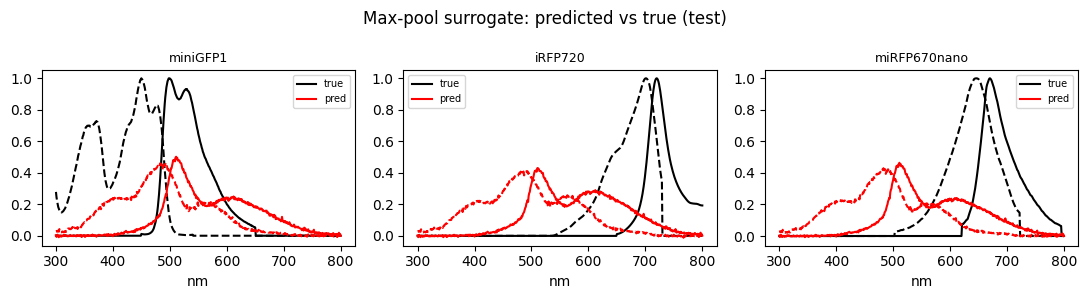

In [8]:
if HAVE_PLT:
    idx=m["test"][:3]
    
    with torch.no_grad(): P=net(Xt[torch.tensor(idx)]).cpu().numpy()
    plt.figure(figsize=(11,3))
    for k,i in enumerate(idx):
        ax=plt.subplot(1,3,k+1); ax.plot(grid,Y[i,:G],"k--"); ax.plot(grid,Y[i,G:],"k-",label="true")
        ax.plot(grid,P[k,:G],"r--"); ax.plot(grid,P[k,G:],"r-",label="pred")
        ax.set_title(rows[i]["name"][:18],fontsize=9); ax.set_xlabel("nm"); ax.legend(fontsize=7)
    plt.suptitle("Max-pool surrogate: predicted vs true (test)"); plt.tight_layout(); plt.show()

## 4. What does max pooling key on?

For each embedding feature, max pooling picks one residue position. If color is set by a few residues, those
positions should concentrate rather than spread uniformly. Histogram of the winning positions (relative to
sequence length) for a few proteins.

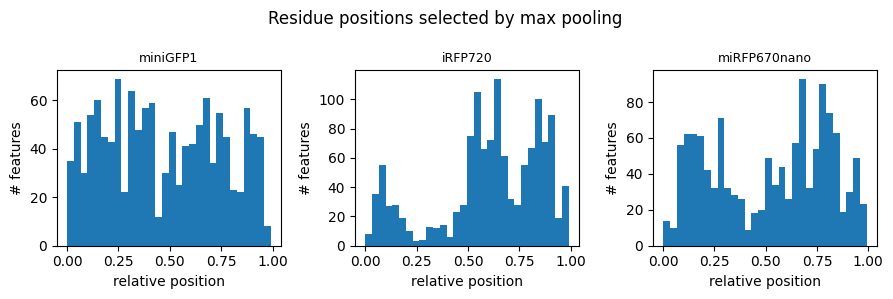

In [9]:
if HAVE_PLT:
    plt.figure(figsize=(9,3))
    for k,i in enumerate(m["test"][:3]):
        h=Hf[i,:Ls[i]]                       # (L,1280)
        argpos=h.argmax(0)                    # winning residue per feature
        ax=plt.subplot(1,3,k+1); ax.hist(argpos/Ls[i],bins=30)
        ax.set_title(rows[i]["name"][:16],fontsize=9); ax.set_xlabel("relative position"); ax.set_ylabel("# features")
    plt.suptitle("Residue positions selected by max pooling"); plt.tight_layout(); plt.show()

## Notes / next

- **Chosen surrogate = max pooling + MLP**, saved to `training_data/surrogate_best.pt` (config records the
  pooling so it can be reconstructed).
- **Attention pooling was implemented but overfits** here (val good, test poor) — the limit is the number of
  distinct families, not the readout. Revisit attention (or LoRA fine-tuning of ESM = Approach 2) if more data
  becomes available, or with chromophore-region–targeted positions.
- To wire into the design pipeline: load this checkpoint and define `g_spectrum(seq)` = MLP( max-pool( per-residue
  ESM emb(seq) ) ). The oracle is untouched for now.